# BTC direction classification — простой backtest

Прогон даёт прикладную интерпретацию balanced accuracy 0.538 на BTC 1h h=1.
Стратегия: long/short по предсказанному знаку, с учётом комиссии и проскальзывания.
Метрики: cumulative return, Sharpe, max drawdown, hit rate, turnover.
Сравнение с buy-and-hold и zero-trade baseline.

Output: `btc_backtest_results.json`. Runtime ≈ 5–10 мин.

In [1]:
import sys, subprocess
def pip(p): subprocess.check_call([sys.executable,'-m','pip','install','--quiet']+p)
pip(['requests','pandas','numpy','scikit-learn','torch'])
print('OK')

OK


In [2]:
import time, json, requests
import numpy as np, pandas as pd
import torch, torch.nn as nn
from sklearn.metrics import balanced_accuracy_score

SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE='cuda' if torch.cuda.is_available() else 'cpu'

In [3]:
# Binance Vision data loader
def download_binance(symbol, interval, days):
    end_ms = int(time.time()*1000); start_ms=end_ms-days*86_400_000
    step={'1m':60_000,'1h':3_600_000,'1d':86_400_000}[interval]
    rows=[]
    while start_ms<end_ms:
        params={'symbol':symbol,'interval':interval,'startTime':start_ms,'limit':1000}
        r=requests.get('https://data-api.binance.vision/api/v3/klines',params=params,timeout=30); r.raise_for_status()
        data=r.json()
        if not data: break
        for k in data: rows.append((k[0], float(k[1]), float(k[2]), float(k[3]), float(k[4]), float(k[5])))
        last=data[-1][0]
        if last+step<=start_ms: break
        start_ms=last+step; time.sleep(0.05)
    df=pd.DataFrame(rows, columns=['ts','o','h','l','c','v']).drop_duplicates('ts').sort_values('ts').reset_index(drop=True)
    df['ds']=pd.to_datetime(df['ts'],unit='ms')
    return df

raw = download_binance('BTCUSDT','1h',730)
print(f'Loaded {len(raw)} hourly candles')

Loaded 17520 hourly candles


In [4]:
# Relative candle features (как в основной части)
df=raw.copy()
R=df['h']-df['l']
R=R.where(R>0, 1e-9)
df['body']=(df['c']-df['o'])/R
df['upper']=(df['h']-df[['o','c']].max(axis=1))/R
df['lower']=(df[['o','c']].min(axis=1)-df['l'])/R
df['dir']=np.sign(df['c']-df['o'])
df['logc']=np.log(df['c']); df['lr']=df['logc'].diff()
df['vol_norm']=np.log(df['v']/df['v'].rolling(50,min_periods=1).mean().clip(1e-9))
df=df.dropna().reset_index(drop=True)

FEATS=['body','upper','lower','dir','lr','vol_norm']
L=128; H=1
N=len(df)

# Build windows
X=np.zeros((N-L-H, L, len(FEATS)),dtype=np.float32)
y=np.zeros(N-L-H, dtype=np.int64)
for i in range(N-L-H):
    X[i]=df[FEATS].iloc[i:i+L].values
    fut_ret = df['lr'].iloc[i+L:i+L+H].sum()
    y[i] = 1 if fut_ret>0 else 0
print(f'Windows: X={X.shape} y_distribution={np.bincount(y)}')

Windows: X=(17390, 128, 6) y_distribution=[8615 8775]


In [5]:
# Train/test chronological split
split=int(len(X)*0.8)
Xtr,Xte=X[:split],X[split:]
ytr,yte=y[:split],y[split:]
# scale features per-feature on train
mu=Xtr.mean(axis=(0,1)); sd=Xtr.std(axis=(0,1)).clip(1e-6)
Xtr=(Xtr-mu)/sd; Xte=(Xte-mu)/sd
print(f'Train: {len(Xtr)}, Test: {len(Xte)}')

Train: 13912, Test: 3478


In [6]:
# Simple Transformer-encoder for direction
class DirTransformer(nn.Module):
    def __init__(self, n_feat, d_model=128, n_heads=4, n_layers=2):
        super().__init__()
        self.proj=nn.Linear(n_feat, d_model)
        self.pos=nn.Parameter(torch.zeros(1, 256, d_model))
        layer=nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=256, dropout=0.1, batch_first=True)
        self.enc=nn.TransformerEncoder(layer, n_layers)
        self.head=nn.Linear(d_model, 2)
    def forward(self,x):
        x=self.proj(x)+self.pos[:,:x.size(1)]
        x=self.enc(x)
        return self.head(x[:,-1])

model=DirTransformer(len(FEATS)).to(DEVICE)
opt=torch.optim.Adam(model.parameters(),lr=1e-4)
crit=nn.CrossEntropyLoss()
Xtr_t=torch.tensor(Xtr).to(DEVICE); ytr_t=torch.tensor(ytr).to(DEVICE)
Xte_t=torch.tensor(Xte).to(DEVICE)
bs=64; epochs=10
for ep in range(epochs):
    model.train()
    perm=torch.randperm(len(Xtr_t))
    losses=[]
    for i in range(0,len(perm),bs):
        idx=perm[i:i+bs]
        opt.zero_grad()
        out=model(Xtr_t[idx])
        loss=crit(out, ytr_t[idx])
        loss.backward(); opt.step()
        losses.append(loss.item())
    model.eval()
    with torch.no_grad(): pred=model(Xte_t).argmax(-1).cpu().numpy()
    bal=balanced_accuracy_score(yte, pred)
    print(f'Epoch {ep+1}: loss={np.mean(losses):.4f} test bal_acc={bal:.4f}')

model.eval()
with torch.no_grad(): proba=torch.softmax(model(Xte_t),-1).cpu().numpy()
pred=proba.argmax(-1)
print(f'Final balanced accuracy: {balanced_accuracy_score(yte,pred):.4f}')

Epoch 1: loss=0.6980 test bal_acc=0.5148
Epoch 2: loss=0.6925 test bal_acc=0.5164
Epoch 3: loss=0.6939 test bal_acc=0.5090
Epoch 4: loss=0.6921 test bal_acc=0.5130
Epoch 5: loss=0.6915 test bal_acc=0.5167
Epoch 6: loss=0.6915 test bal_acc=0.5153
Epoch 7: loss=0.6917 test bal_acc=0.5152
Epoch 8: loss=0.6907 test bal_acc=0.5205
Epoch 9: loss=0.6901 test bal_acc=0.5082
Epoch 10: loss=0.6896 test bal_acc=0.5152
Final balanced accuracy: 0.5152


In [7]:
# === BACKTEST ===
# Стратегия: long/flat (если pred==1 — long на 1 бар; иначе flat)
# и long/short (если pred==1 — long, иначе short)
# Доходность бара = log-return следующего бара

test_lr = df['lr'].iloc[split+L+H : split+L+H+len(yte)].values  # доходность бара t+L+1 (т.е. таргет)
assert len(test_lr) == len(yte), f'{len(test_lr)} vs {len(yte)}'

FEE = 0.0005   # 5 bps в одну сторону (taker)
SLIP = 0.0001  # 1 bp проскальзывания

def backtest(strategy_pos, lr, fee=FEE, slip=SLIP):
    """strategy_pos: array {-1, 0, 1} — позиция перед закрытием бара"""
    pos=np.asarray(strategy_pos)
    # Стоимость смены позиции
    pos_prev = np.concatenate([[0], pos[:-1]])
    turnover = np.abs(pos - pos_prev).sum() / len(pos)  # средний turnover за бар
    cost = np.abs(pos - pos_prev) * (fee + slip)
    pnl = pos * lr - cost
    cum = np.exp(np.cumsum(pnl))
    # Метрики
    final = cum[-1] - 1
    bar_per_year = 24*365
    sharpe = pnl.mean() / (pnl.std()+1e-9) * np.sqrt(bar_per_year)
    rolling_max = np.maximum.accumulate(cum)
    dd = (cum - rolling_max) / rolling_max
    max_dd = dd.min()
    hit_rate = ((pos != 0) & (np.sign(pos) == np.sign(lr))).sum() / max(1, (pos!=0).sum())
    return {'final_return': float(final), 'sharpe': float(sharpe), 'max_drawdown': float(max_dd), 'hit_rate': float(hit_rate), 'turnover_per_bar': float(turnover), 'total_costs': float(cost.sum()), 'cum_curve': cum.tolist()}

# 1. Buy-and-hold
bh_pos = np.ones(len(yte))
bh = backtest(bh_pos, test_lr)
# 2. Zero-trade (cash)
zt = backtest(np.zeros(len(yte)), test_lr)
# 3. Long/flat по predication
lf_pos = np.where(pred==1, 1, 0)
lf = backtest(lf_pos, test_lr)
# 4. Long/short по predication
ls_pos = np.where(pred==1, 1, -1)
ls = backtest(ls_pos, test_lr)
# 5. Confidence threshold (только когда |proba-0.5|>0.05)
conf=np.abs(proba[:,1]-0.5)
lsc_pos = np.where(conf>0.05, np.where(pred==1,1,-1), 0)
lsc = backtest(lsc_pos, test_lr)

results = {
    'metadata':{'test_bars':int(len(yte)),'split_idx':int(split),'fee':FEE,'slip':SLIP,'balanced_accuracy_test':float(balanced_accuracy_score(yte,pred))},
    'strategies':{
        'BuyAndHold':{k:v for k,v in bh.items() if k!='cum_curve'},
        'ZeroTrade':{k:v for k,v in zt.items() if k!='cum_curve'},
        'LongFlat':{k:v for k,v in lf.items() if k!='cum_curve'},
        'LongShort':{k:v for k,v in ls.items() if k!='cum_curve'},
        'LongShortConfThr':{k:v for k,v in lsc.items() if k!='cum_curve'},
    }
}
print(json.dumps(results, indent=2, ensure_ascii=False))
with open('btc_backtest_results.json','w') as f:
    json.dump(results,f,indent=2,ensure_ascii=False)

{
  "metadata": {
    "test_bars": 3478,
    "split_idx": 13912,
    "fee": 0.0005,
    "slip": 0.0001,
    "balanced_accuracy_test": 0.5151700335414338
  },
  "strategies": {
    "BuyAndHold": {
      "final_return": -0.1746158924895299,
      "sharpe": -1.0205925324436105,
      "max_drawdown": -0.35589760225970374,
      "hit_rate": 0.4974123059229442,
      "turnover_per_bar": 0.0002875215641173088,
      "total_costs": 0.0006000000000000001
    },
    "ZeroTrade": {
      "final_return": 0.0,
      "sharpe": 0.0,
      "max_drawdown": 0.0,
      "hit_rate": 0.0,
      "turnover_per_bar": 0.0,
      "total_costs": 0.0
    },
    "LongFlat": {
      "final_return": -0.5510107664472623,
      "sharpe": -5.549848907010734,
      "max_drawdown": -0.5791824783878248,
      "hit_rate": 0.5300733496332518,
      "turnover_per_bar": 0.487924094307073,
      "total_costs": 1.0182
    },
    "LongShort": {
      "final_return": -0.7557605846636425,
      "sharpe": -7.462203833424735,
      "

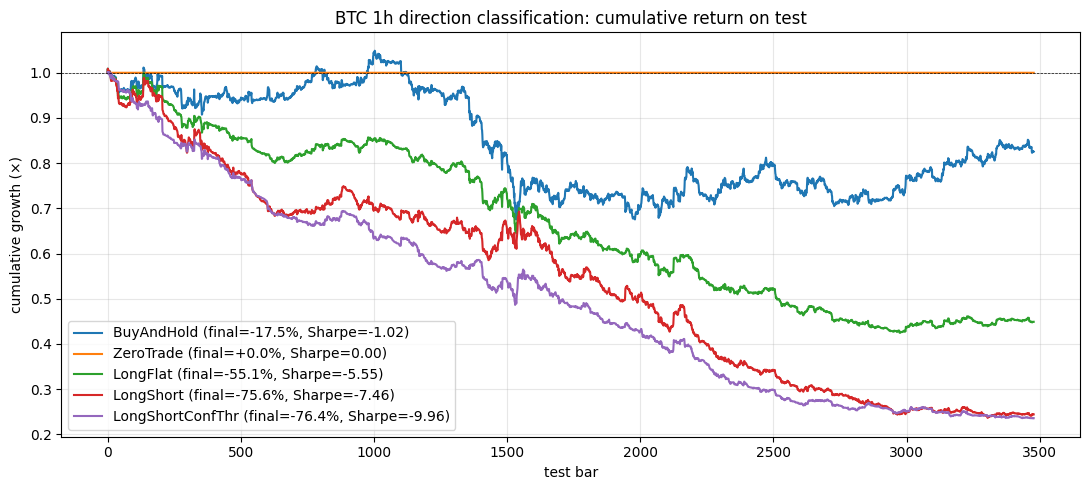

Saved btc_backtest_results.json and btc_backtest.png


In [8]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(11,5))
for name,r in [('BuyAndHold',bh),('ZeroTrade',zt),('LongFlat',lf),('LongShort',ls),('LongShortConfThr',lsc)]:
    ax.plot(r['cum_curve'], label=f'{name} (final={r["final_return"]*100:+.1f}%, Sharpe={r["sharpe"]:.2f})')
ax.legend(); ax.set_title('BTC 1h direction classification: cumulative return on test')
ax.set_xlabel('test bar'); ax.set_ylabel('cumulative growth (×)')
ax.axhline(1.0, color='k', linewidth=0.5, linestyle='--')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('btc_backtest.png', dpi=120)
plt.show()
print('Saved btc_backtest_results.json and btc_backtest.png')